In [1]:
# 8W Male
import pandas as pd

In [2]:
# Good resource for TF - target genes: https://www.grnpedia.org/trrust/key_regulator/015fc0d93c.php

In [9]:
quadrant_0_male = pd.read_csv('../data/taPVAT_Adipocytes_Brown_Male_MetaDEGs_Quadrant_0.csv')
quadrant_3_male = pd.read_csv('../data/taPVAT_Adipocytes_Brown_Male_MetaDEGs_Quadrant_3.csv')

In [2]:

df_Adipocytes_Brown = pd.read_csv('../../predictions/gene_scores/August18_10_19_gene_scores_Adipocytes_Brown_8W_M.csv')


In [5]:

df_Adipocytes_Brown


,Unnamed: 0,Gene,Score
0,0,6330411D24Rik,-0.053172
1,1,AABR07000398.1,1.589055
2,2,AABR07001902.1,-0.018638
3,3,AABR07001942.1,-0.077581
4,4,AABR07002969.1,-0.321621
...,...,...,...
4995,4995,Znrf1,0.894105
4996,4996,Zp2,-0.033152
4997,4997,Zpbp,-0.006565
4998,4998,Zswim6,1.817269


In [6]:
df_Adipocytes_Brown = df_Adipocytes_Brown[~df_Adipocytes_Brown['Gene'].str.startswith('Mt-')] # Removed mitochondrial genes
df_Adipocytes_Brown = df_Adipocytes_Brown[~df_Adipocytes_Brown['Gene'].str.startswith('AABR')]
df_Adipocytes_Brown = df_Adipocytes_Brown[~df_Adipocytes_Brown['Gene'].str.startswith('ENSRN')]

In [7]:
pval = 1.0

In [8]:
df_Adipocytes_Brown[df_Adipocytes_Brown['Gene'].str.startswith('Creb')]

,Unnamed: 0,Gene,Score
957,957,Creb3l1,-0.116919
958,958,Creb5,0.605651


In [10]:
# Add a new column with the absolute value of the score

df_Adipocytes_Brown['abs_score'] = df_Adipocytes_Brown['Score'].abs()


# Sort by absolute score

top_abs_Adipocytes_Brown = df_Adipocytes_Brown.sort_values('abs_score', ascending=False).head(50)



In [11]:
significant_quad_3 = quadrant_3_male[quadrant_3_male['pval']<pval]
significant_quad_3 = significant_quad_3[~significant_quad_3['gene_id'].str.startswith('Mt-')]
significant_quad_3 = significant_quad_3[~significant_quad_3['gene_id'].str.startswith('AABR')]
significant_quad_3 = significant_quad_3[~significant_quad_3['gene_id'].str.startswith('ENSRN')]


In [12]:
significant_quad_3

,gene_id,gene_id.1,celltype,group,sub_id,sub_id_2,log2FoldChange_Control,lfcSE_Control,log2FoldChange_HF,lfcSE_HF,log2FC_diff,se_delta,z,pval,padj_diff
0,Pde10a,Pde10a,Adipocytes_Brown,time,Control,M,-4.944918,0.598814,-0.897037,0.708053,-4.047881,0.927317,-4.365155,0.000013,0.150915
1,Slc22a1,Slc22a1,Adipocytes_Brown,time,Control,M,-6.649179,2.450159,-2.996657,1.166783,-3.652522,2.713791,-1.345912,0.178331,0.999957
2,Lyz2,Lyz2,Adipocytes_Brown,time,Control,M,-4.349670,1.134708,-1.428476,0.746823,-2.921194,1.358421,-2.150433,0.031521,0.999957
3,Axdnd1,Axdnd1,Adipocytes_Brown,time,Control,M,-3.057039,0.755674,-0.652973,0.749907,-2.404065,1.064614,-2.258157,0.023936,0.999957
4,Adam11,Adam11,Adipocytes_Brown,time,Control,M,-2.617882,1.178299,0.251553,0.744475,-2.366328,1.393783,-1.697773,0.089551,0.999957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,Fbxo5,Fbxo5,Adipocytes_Brown,time,Control,M,-1.554340,0.605849,-0.612459,0.471670,-0.941881,0.767806,-1.226719,0.219928,0.999957
126,RGD1564053,RGD1564053,Adipocytes_Brown,time,Control,M,-1.185721,0.906912,-0.244486,0.822720,-0.941235,1.224483,-0.768680,0.442083,0.999957
127,Sh3gl2,Sh3gl2,Adipocytes_Brown,time,Control,M,-1.307443,0.748306,-0.368156,0.682266,-0.939287,1.012644,-0.927559,0.353636,0.999957
128,Ddc,Ddc,Adipocytes_Brown,time,Control,M,-0.958819,0.751318,-0.021425,0.635872,-0.937394,0.984282,-0.952363,0.340913,0.999957


In [13]:
significant_quad_0 = quadrant_0_male[quadrant_0_male['pval']<pval]
significant_quad_0 = significant_quad_0[~significant_quad_0['gene_id'].str.startswith('Mt-')]
significant_quad_0 = significant_quad_0[~significant_quad_0['gene_id'].str.startswith('AABR')]
significant_quad_0 = significant_quad_0[~significant_quad_0['gene_id'].str.startswith('ENSRN')]




In [14]:
genes_that_went_up_in_HF = list(significant_quad_0['gene_id'])
genes_that_went_down_in_control = list(significant_quad_3['gene_id'])

In [15]:
df_Adipocytes_Brown['Score'].sort_values(ascending=False)

336     8.796266
2941    7.315664
730     5.778465
2913    5.694440
744     5.225469
          ...   
4050   -2.350351
3123   -2.920293
111    -3.004843
1841   -3.090478
103    -3.129629
Name: Score, Length: 4545, dtype: float64

In [16]:
mask = (df_Adipocytes_Brown['Score'] > 0) & \
       (df_Adipocytes_Brown['Gene'].isin(genes_that_went_up_in_HF) |
        df_Adipocytes_Brown['Gene'].isin(genes_that_went_down_in_control))

df_filtered = df_Adipocytes_Brown[mask]

In [17]:
df_filtered.sort_values('Score',ascending=False)

,Unnamed: 0,Gene,Score,abs_score
4447,4447,Sulf1,4.597894,4.597894
389,389,Atp8b1,3.207906,3.207906
2255,2255,Igfbp7,2.933813,2.933813
4433,4433,Stox2,2.350992,2.350992
3813,3813,Rapgef5,2.091635,2.091635
3280,3280,Nxn,1.980741,1.980741
3385,3385,Pam,1.012750,1.012750
2834,2834,Ltbp1,0.884801,0.884801
3122,3122,Nav2,0.647712,0.647712
4775,4775,Trpv4,0.507868,0.507868


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming df_Adipocytes_Brown is already loaded and contains 'Gene' and 'Score' columns

# Top 20 most positive gene scores
top_pos = df_Adipocytes_Brown.sort_values('Score', ascending=False).head(20)

plt.figure(dpi=300)
plt.bar(top_pos['Gene'], top_pos['Score'], color='darkgreen')
plt.xticks(rotation=90, fontsize=12)
plt.ylabel("scVIDR Gene Score", fontsize=14)
plt.title("Top 20 Positive Gene Scores", fontsize=16)
plt.tight_layout()
plt.savefig("../figures/Top20PositiveGeneScores_24W_Brown_Adipocytes_Both.svg", bbox_inches="tight")
plt.show()

# Top 20 most negative gene scores
top_neg = df_Adipocytes_Brown.sort_values('Score', ascending=True).head(20)

plt.figure(dpi=300)
plt.bar(top_neg['Gene'], top_neg['Score'], color='darkred')
plt.xticks(rotation=90, fontsize=12)
plt.ylabel("scVIDR Gene Score", fontsize=14)
plt.title("Top 20 Negative Gene Scores", fontsize=16)

plt.tight_layout()
plt.savefig("../figures/Top20NegativeGeneScores_24W_Brown_Adipocytes_Both.svg", bbox_inches="tight")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the data


# Sort by absolute value of score
df_Adipocytes_Brown['abs_score'] = df_Adipocytes_Brown['Score'].abs()
top_genes_df = df_Adipocytes_Brown.sort_values('abs_score', ascending=False).head(20)

# Plot
plt.figure(dpi=300)
plt.bar(top_genes_df['Gene'], top_genes_df['Score'])
plt.xticks(rotation=90, fontsize=12)
plt.ylabel(r"scVIDR Gene Score", fontsize=18)
plt.tight_layout()
#plt.savefig("../figures/4A.svg", bbox_inches="tight")
plt.show()


In [ ]:
import gseapy as gp
import pandas as pd


# Rank by absolute score
df_Adipocytes_Brown['abs_score'] = df_Adipocytes_Brown['Score'].abs()
top_genes = df_Adipocytes_Brown.sort_values('abs_score', ascending=False).head(100)

# Extract gene list
glist = top_genes['Gene'].tolist()

glist_top_increase = df_Adipocytes_Brown.sort_values('Score', ascending=False).head(100)
glist_top_increase = glist_top_increase['Gene'].tolist()
# Enrichment analysis
enr = gp.enrichr(
    gene_list=glist_top_increase,
    gene_sets= ["GO_Biological_Process_2023"], #["WikiPathways_2024_Mouse"],
    organism='Mouse',
    #description='adipocytes_brown_top100',
    #outdir='results/enrichr_adipocytes_brown',
    cutoff=0.5  # relaxed cutoff
)

gp.plot.barplot(enr.results,title='Enrichr Analysis of Gene Scores \n for Genes that Increase Along Perturbation Axis',fs = 8, top_term = 20)
#plt.savefig("../figures/4B.svg", bbox_inches = "tight")
# enr.results.head(10)

In [ ]:
import gseapy as gp
import pandas as pd

# Load gene scores
df_Adipocytes_Brown = pd.read_csv('../predictions/gene_scores/gene_scores_Adipocytes_Brown_8W.csv')

# Rank by absolute score
df_Adipocytes_Brown['abs_score'] = df_Adipocytes_Brown['Score'].abs()

glist_top_decrease = df_Adipocytes_Brown.sort_values('Score', ascending=True).head(100)
glist_top_decrease = glist_top_decrease['Gene'].tolist()

print(glist_top_decrease)
# Enrichment analysis
enr = gp.enrichr(
    gene_list=glist_top_decrease,
    gene_sets=["GO_Biological_Process_2023"], #["GO_Biological_Process_2023"],
    organism='Mouse',
    #description='adipocytes_brown_top100',
    #outdir='results/enrichr_adipocytes_brown',
    cutoff=0.5  # relaxed cutoff
)
enr.results.head(10)
gp.plot.barplot(enr.results,title='Enrichr Analysis of Gene Scores \n for Genes that Decrease Along Perturbation Axis',fs = 8, top_term = 20)
#plt.savefig("../figures/4B.svg", bbox_inches = "tight")




In [ ]:
gp.plot.barplot(enr.results,title='Enrichr Analysis of Gene Scores \n for Bottom ',fs = 8, top_term = 20)

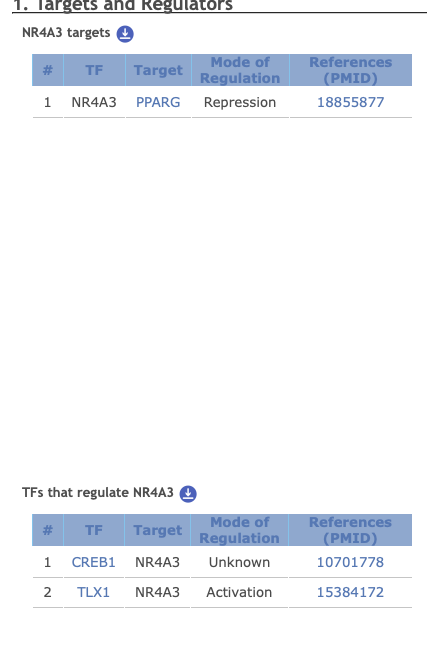

In [ ]:
# 1	NR4A1	BABAM2	Repression	22159226
# 2	NR4A1	CCNA2	Repression	12842839
# 3	NR4A1	CDKN1B	Activation	12842839
# 4	NR4A1	CYP11A1	Unknown	20083153
# 5	NR4A1	CYP17A1	Unknown	20083153
# 6	NR4A1	E2F1	Activation	12947120
# 7	NR4A1	FASLG	Unknown	14563113
# 8	NR4A1	HSD3B2	Activation	15666793
# 9	NR4A1	HSD3B2	Unknown	15208301; 20083153; 23874725
# 10	NR4A1	MDM2	Repression	17139261
# 11	NR4A1	MMP2	Activation	22551568
# 12	NR4A1	RNF7	Repression	22159226
# 13	NR4A1	SERPINE1	Unknown	12506026
# 14	NR4A1	STAR	Unknown	20083153
# 15	NR4A1	TIMP2	Activation	22551568
# 16	NR4A1	TNF	Repression	19213954




### Regulators of NR4A1:
# TFs that regulate NR4A1  
# #	TF	Target	Mode of Regulation	References
# (PMID)
# 1	HDAC7	NR4A1	Unknown	15623513
# 2	HIF1A	NR4A1	Activation	14729605
# 3	MEF2C	NR4A1	Repression	18079734
# 4	PML	NR4A1	Repression	12032831
# 5	SP1	NR4A1	Unknown	8961265

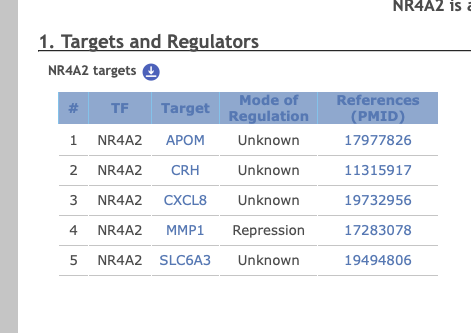

In [ ]:
glist_top_increase